# 01 — Exploratory Data Analysis: Albania (PISA 2009–2022)

**Project:** Predicting Albanian Student Low-Proficiency Risk — A Comparative ML Framework

This notebook explores the Albanian longitudinal dataset (27,042 students, five cycles). All statistics use PISA sampling weights (`W_FSTUWT`). Logic lives in `src/`; this notebook is the narrative layer.

**Key question addressed here:** How did Albania's low-proficiency risk evolve, and what does the dramatic 2018→2022 reversal look like in the data?

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.features.target import add_all_targets
from src.data.weights import weighted_mean, weighted_proportion, weighted_std

df = add_all_targets(pd.read_parquet('../data/processed/albania_longitudinal.parquet'))
print('Rows:', len(df), '| Cycles:', sorted(df.CYCLE.unique()))
df[['CYCLE','MATH_PV_MEAN','ESCS','HOMEPOS','AT_RISK_MATH','W_FSTUWT']].head()

2026-06-29 18:36:03 [info     ] Point target added             at_risk_rate=0.602 domain=math threshold=420.0


2026-06-29 18:36:03 [info     ] Point target added             at_risk_rate=0.575 domain=reading threshold=407.0


2026-06-29 18:36:04 [info     ] Point target added             at_risk_rate=0.542 domain=science threshold=410.0


Rows: 27042 | Cycles: [np.int64(2009), np.int64(2012), np.int64(2015), np.int64(2018), np.int64(2022)]


,CYCLE,MATH_PV_MEAN,ESCS,HOMEPOS,AT_RISK_MATH,W_FSTUWT
0,2009,456.154,-1.1272,-2.8545,0,2.9443
1,2009,449.922,0.5878,-1.4413,0,2.9443
2,2009,408.796,-0.3142,-1.6609,1,2.9443
3,2009,247.242,-0.0151,-1.0950,1,2.9443
4,2009,388.154,0.9859,-0.7652,1,2.9443


## 1. Target trajectory — the V-shaped crisis

Weighted low-proficiency rate (math score < 420, below PISA Level 2) and mean score by cycle.

In [3]:
rows = []
for c in sorted(df.CYCLE.unique()):
    s = df[df.CYCLE==c]; w = s['W_FSTUWT']
    p = weighted_proportion(s['AT_RISK_MATH'], w); n=len(s)
    rows.append({'cycle':int(c),'N':n,
                 'at_risk_%':round(p*100,1),
                 'ci95':round(1.96*np.sqrt(p*(1-p)/n)*100,2),
                 'mean_score':round(weighted_mean(s['MATH_PV_MEAN'],w),1),
                 'mean_ESCS':round(weighted_mean(s['ESCS'],w),3)})
pd.DataFrame(rows)

,cycle,N,at_risk_%,ci95,mean_score,mean_ESCS
0,2009,4596,69.3,1.33,377.5,-0.955
1,2012,4743,62.6,1.38,394.3,NaN
2,2015,5215,54.5,1.35,413.2,NaN
3,2018,6359,41.9,1.21,437.2,-0.872
4,2022,6129,75.3,1.08,368.2,-0.751


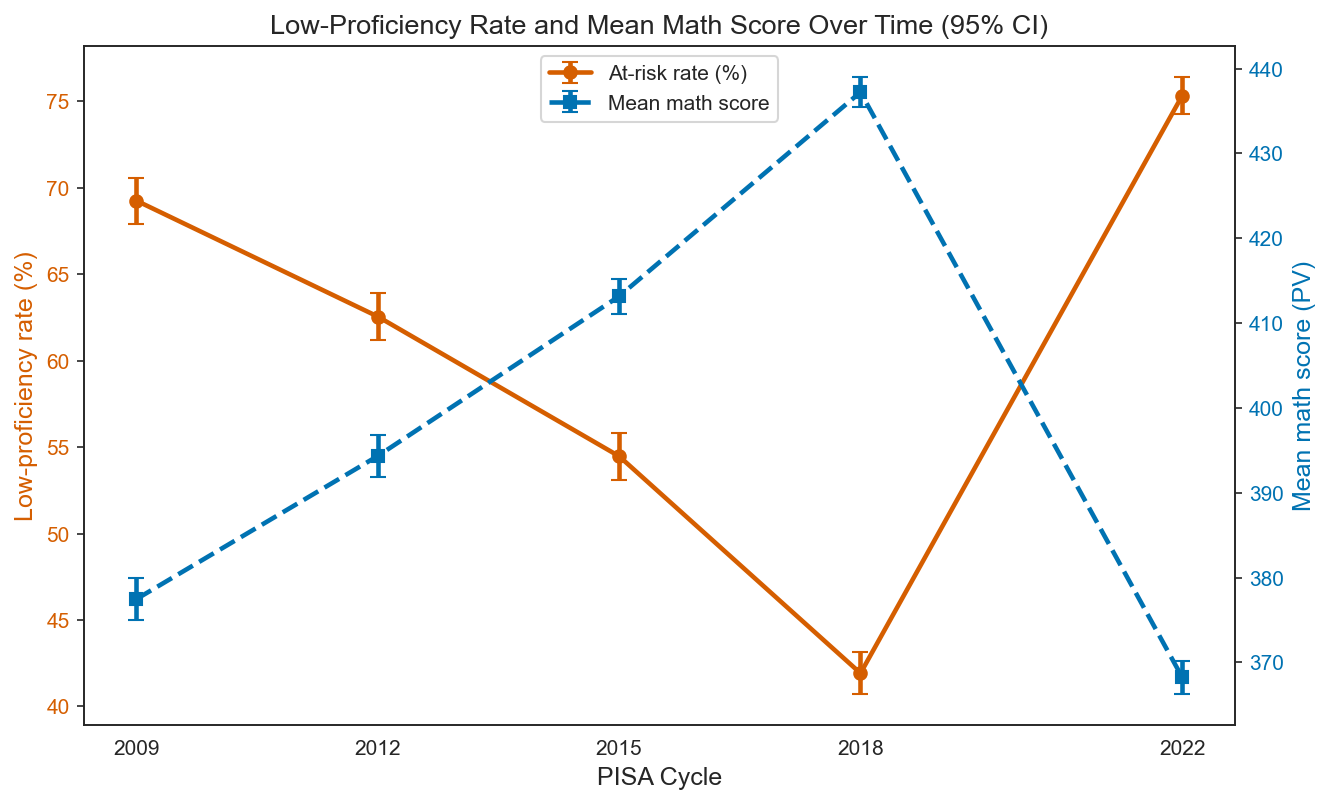

In [4]:
from src.visualization.eda import plot_atrisk_trajectory
fig = plot_atrisk_trajectory(df); plt.show()

**Reading:** Albania improved steadily 2009→2018 (low-proficiency fell ~28 pp), then reversed catastrophically in 2022 (+33 pp). This single-cycle reversal is the focus of the paper.

## 2. Score distributions by cycle

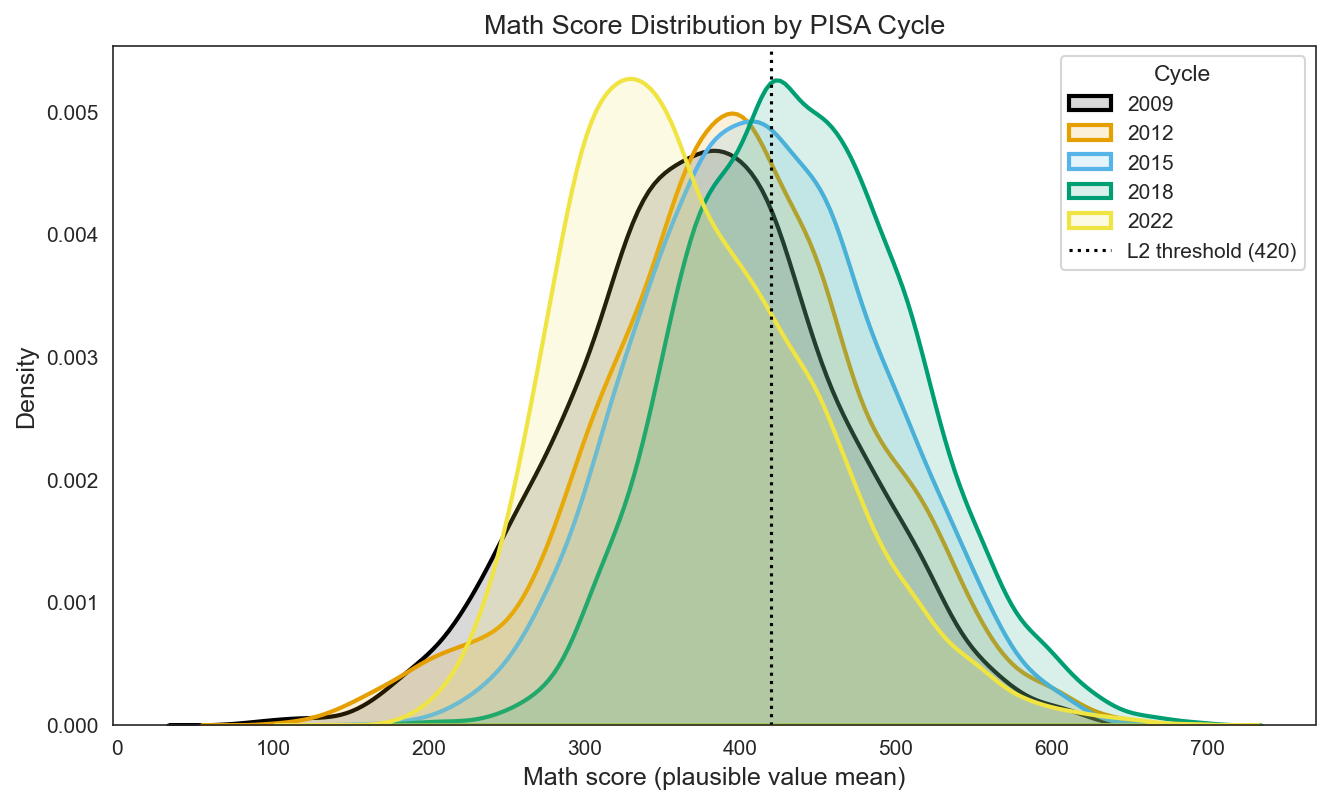

In [5]:
from src.visualization.eda import plot_score_distributions
fig = plot_score_distributions(df); plt.show()

## 3. Feature availability / missingness

Which background indices are present in each cycle? The 2015 column is the Albania-specific gap (OECD did not compute background indices for Albania that cycle).

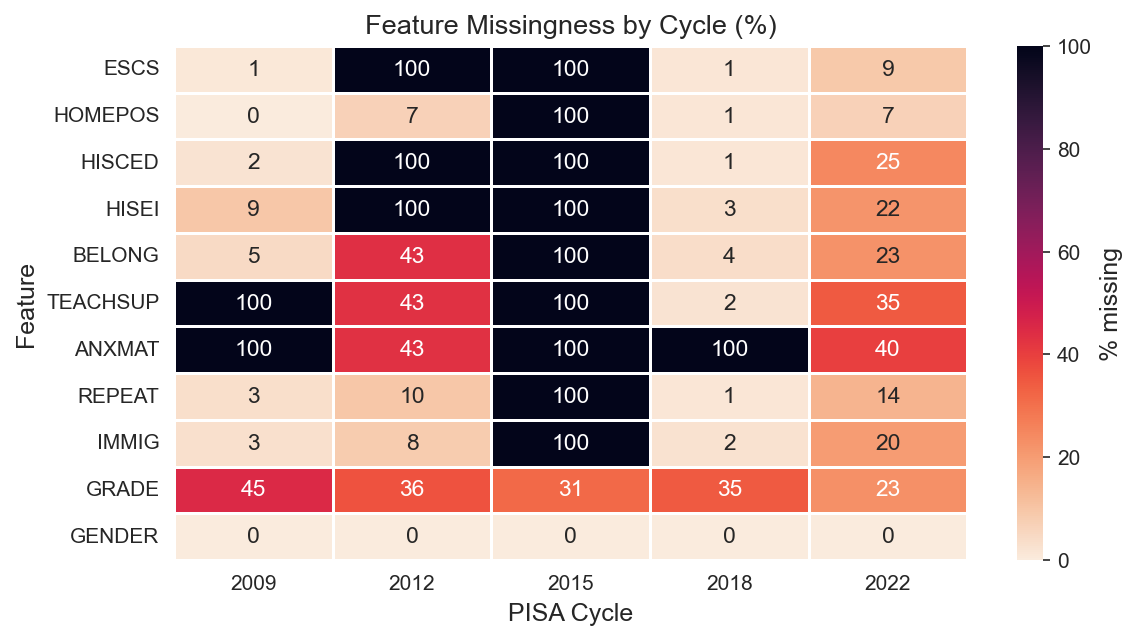

In [6]:
from src.visualization.eda import plot_missingness_heatmap
feats = ['ESCS','HOMEPOS','HISCED','HISEI','BELONG','TEACHSUP','ANXMAT','REPEAT','IMMIG','GRADE','GENDER']
fig = plot_missingness_heatmap(df, feats); plt.show()

## 4. Socioeconomic gradient — SES quintile × at-risk

Weighted low-proficiency rate by HOMEPOS/ESCS quintile across cycles.

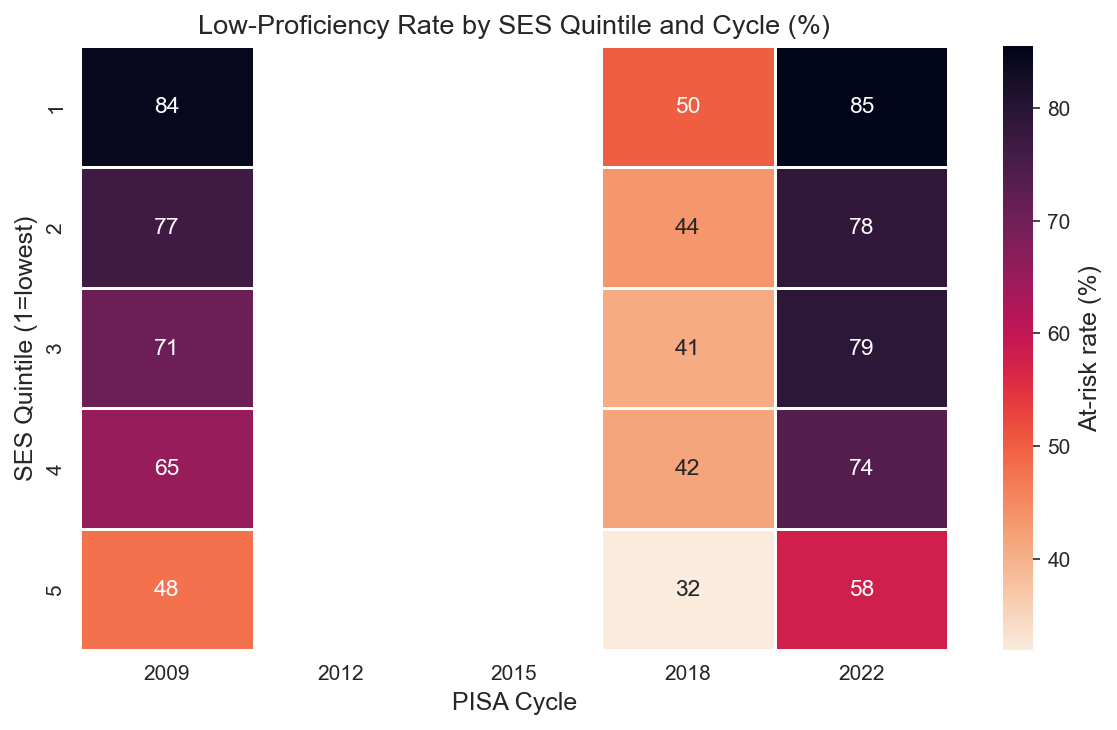

In [7]:
from src.visualization.eda import plot_ses_quintile_heatmap
fig = plot_ses_quintile_heatmap(df); plt.show()

## 5. Feature correlation structure

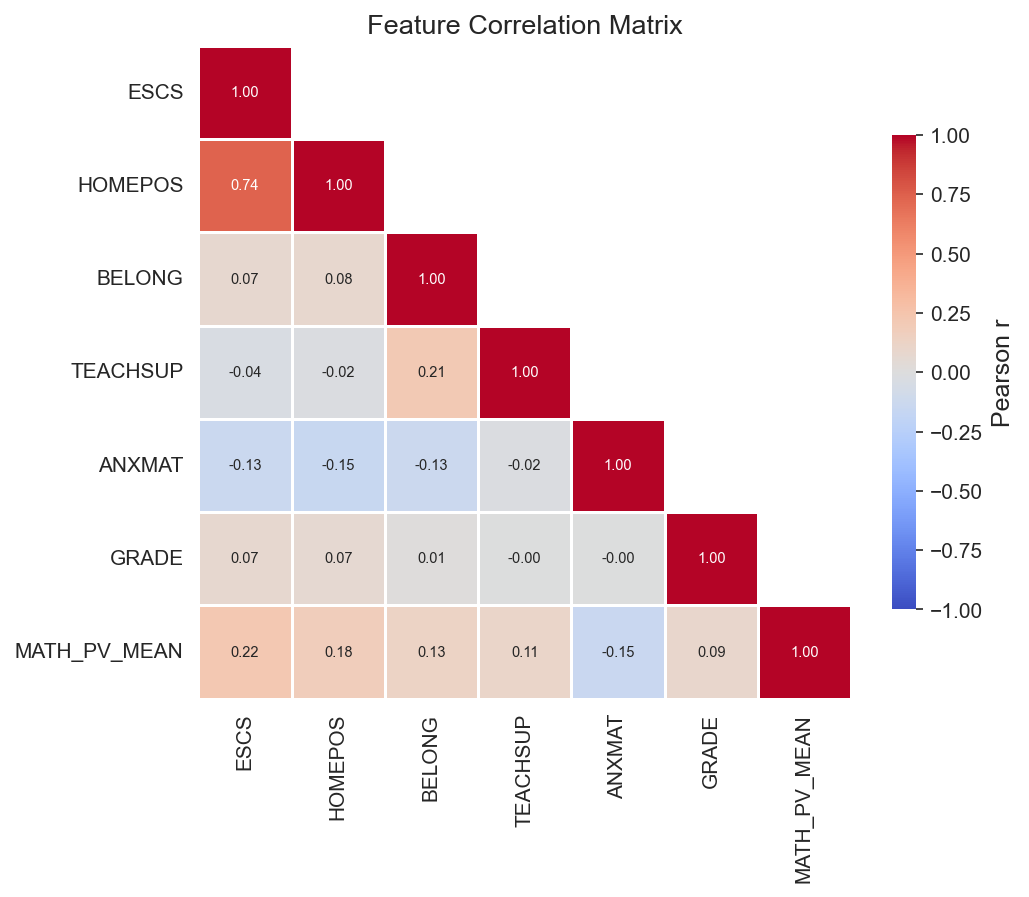

In [8]:
from src.visualization.eda import plot_correlation_matrix
fig = plot_correlation_matrix(df, ['ESCS','HOMEPOS','BELONG','TEACHSUP','ANXMAT','GRADE','MATH_PV_MEAN'])
plt.show()

## 6. The 2022 crisis — feature drift (2018 → 2022)

Standardized mean difference (Cohen's d) of each feature between the 2018 baseline and the 2022 crisis cohort. This previews the covariate-shift analysis in notebook 03.

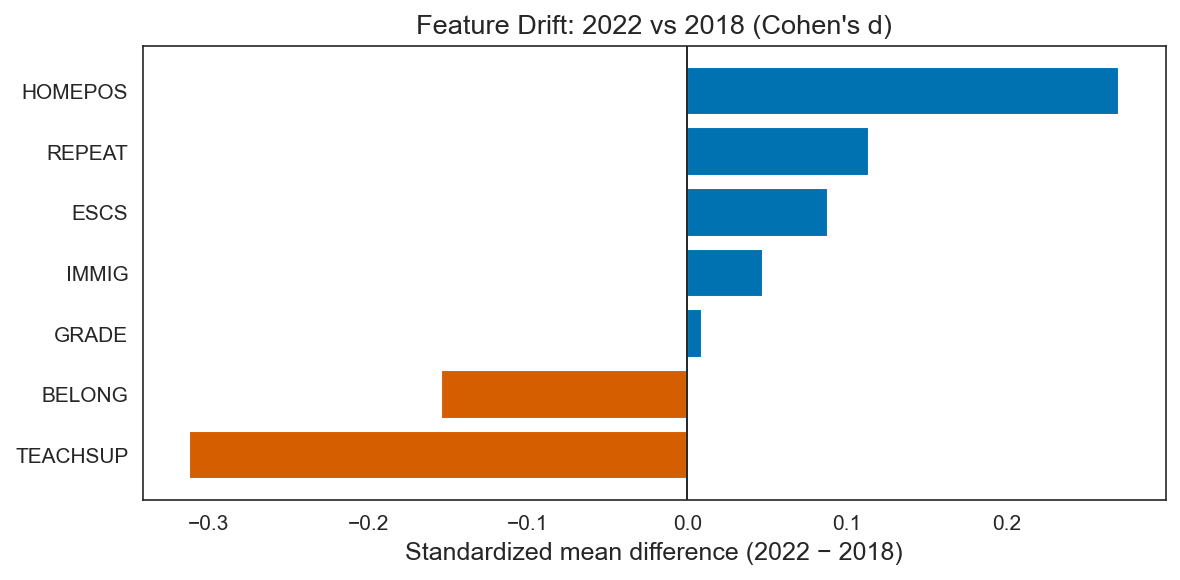

In [9]:
from src.visualization.eda import plot_feature_drift
fig = plot_feature_drift(df, ['ESCS','HOMEPOS','BELONG','TEACHSUP','ANXMAT','GRADE','REPEAT','IMMIG'])
plt.show()

**Takeaway:** Teacher support (TEACHSUP) shows the largest negative drift into 2022, while home possessions (HOMEPOS) shifts positively — the crisis is not a simple SES story.